<a href="https://colab.research.google.com/github/vandanacm/spring-quarter-2026/blob/main/EEC289Q_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEC 289Q - Homework 1: Linear & Polynomial Regression

This notebook walks through simple linear regression (least squares, gradient descent, and `sklearn`), polynomial regression on noisy data, and multiple regression on the California housing dataset. The random seed is fixed so the train/test split and synthetic data stay consistent across parts.


## Environment setup

In [ ]:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

---

# Part A — Simple Linear Regression (synthetic data)

We generate \(Y = 5X + 10 + \epsilon\) with \(\epsilon \sim \mathcal{N}(0,1)\), visualize it, and hold an **80/20** train/test split (`random_state=42`) for all three implementations.

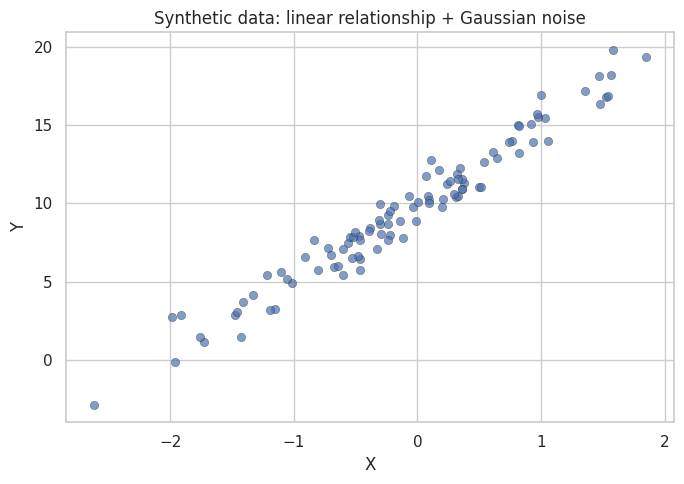

Train size: 80 | Test size: 20


In [ ]:
n_samples = 100
true_m, true_c = 5.0, 10.0
sigma = 1.0

X_syn = np.random.randn(n_samples)
noise = np.random.normal(0.0, sigma, size=n_samples)
Y_syn = true_m * X_syn + true_c + noise

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_syn, Y_syn, alpha=0.7, edgecolors="k", linewidths=0.3)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Synthetic data: linear relationship + Gaussian noise")
plt.tight_layout()
plt.show()

X_2d = X_syn.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, Y_syn, test_size=0.2, random_state=42
)
X_train_r = X_train.ravel()
X_test_r = X_test.ravel()
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

## A.1 — Least squares
Closed form:
\[
m = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}, \quad c = \bar{y} - m\bar{x}
\]

\[
\mathrm{MSE} = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2, \quad
R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}
\]

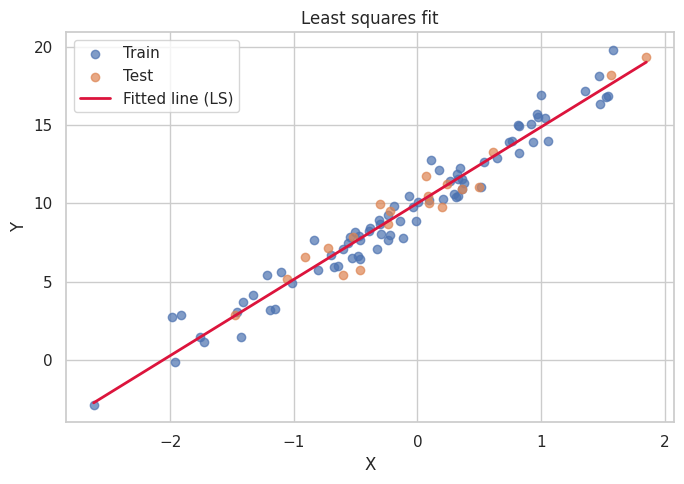

Least squares — slope m = 4.858509, intercept c = 10.014587
Train — MSE: 0.886392, R²: 0.958381
Test  — MSE: 0.872849, R²: 0.943494


In [ ]:
def least_squares_coefficients(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    x_bar, y_bar = x.mean(), y.mean()
    denom = np.sum((x - x_bar) ** 2)
    if denom == 0:
        raise ValueError("Zero variance in x")
    m = np.sum((x - x_bar) * (y - y_bar)) / denom
    c = y_bar - m * x_bar
    return float(m), float(c)


def mean_squared_error_scratch(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    return float(np.mean((y_true - y_pred) ** 2))


def r2_score_scratch(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return float(1.0 - ss_res / ss_tot)


m_ls, c_ls = least_squares_coefficients(X_train_r, y_train)
y_train_pred_ls = m_ls * X_train_r + c_ls
y_test_pred_ls = m_ls * X_test_r + c_ls

x_line = np.linspace(X_syn.min(), X_syn.max(), 200)
y_line = m_ls * x_line + c_ls

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train_r, y_train, label="Train", alpha=0.7)
ax.scatter(X_test_r, y_test, label="Test", alpha=0.7)
ax.plot(x_line, y_line, color="crimson", lw=2, label="Fitted line (LS)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.set_title("Least squares fit")
plt.tight_layout()
plt.show()

print("Least squares — slope m = {:.6f}, intercept c = {:.6f}".format(m_ls, c_ls))
print("Train — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_train, y_train_pred_ls),
    r2_score_scratch(y_train, y_train_pred_ls),
))
print("Test  — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_test, y_test_pred_ls),
    r2_score_scratch(y_test, y_test_pred_ls),
))

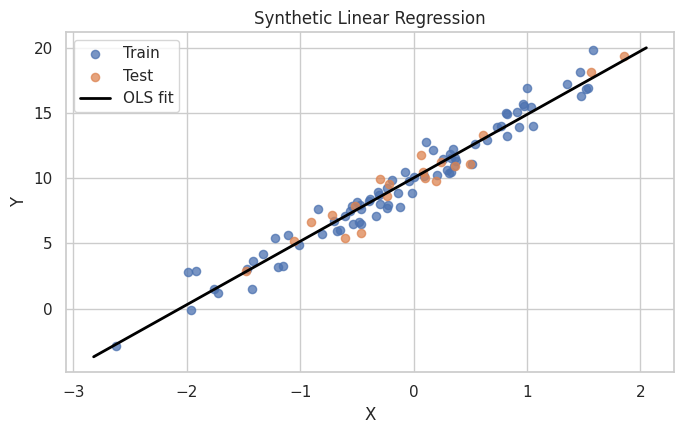

In [ ]:
#Synthetic linear regression with fitted OLS line

ols_model_for_plot = LinearRegression()
ols_model_for_plot.fit(X_train, y_train)

x_line_report = np.linspace(X_syn.min() - 0.2, X_syn.max() + 0.2, 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_train_r, y_train, s=35, alpha=0.75, label="Train")
ax.scatter(X_test_r, y_test, s=35, alpha=0.75, label="Test")
ax.plot(
    x_line_report.ravel(),
    ols_model_for_plot.predict(x_line_report),
    color="black",
    lw=2,
    label="OLS fit",
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Synthetic Linear Regression")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## A.2 — Gradient descent

We minimize the **sum** of squared errors.

Learning rate = **0.0001**, **10000** iterations — as specified.

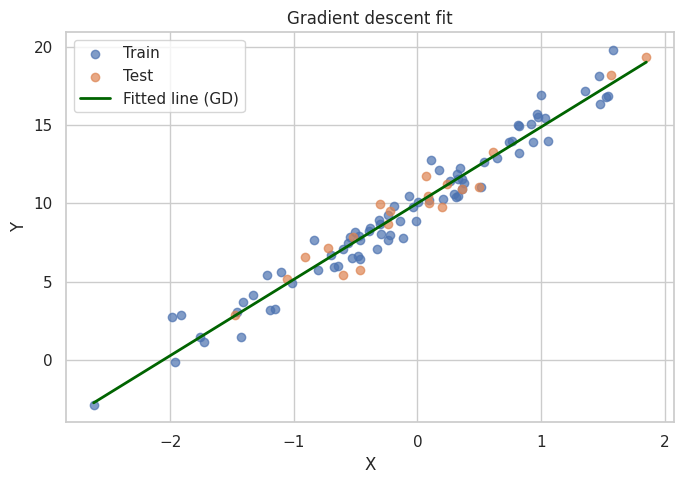

Gradient descent — slope m = 4.858509, intercept c = 10.014587
Train — MSE: 0.886392, R²: 0.958381
Test  — MSE: 0.872849, R²: 0.943494


In [ ]:
def gradient_descent_linear(x, y, learning_rate=0.0001, n_iterations=10000):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    m, c = 0.0, 0.0
    for _ in range(n_iterations):
        y_hat = m * x + c
        err = y - y_hat
        grad_m = -2.0 * np.sum(x * err)
        grad_c = -2.0 * np.sum(err)
        m -= learning_rate * grad_m
        c -= learning_rate * grad_c
    return float(m), float(c)


m_gd, c_gd = gradient_descent_linear(X_train_r, y_train, learning_rate=0.0001, n_iterations=10000)
y_train_pred_gd = m_gd * X_train_r + c_gd
y_test_pred_gd = m_gd * X_test_r + c_gd

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train_r, y_train, label="Train", alpha=0.7)
ax.scatter(X_test_r, y_test, label="Test", alpha=0.7)
ax.plot(x_line, m_gd * x_line + c_gd, color="darkgreen", lw=2, label="Fitted line (GD)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.set_title("Gradient descent fit")
plt.tight_layout()
plt.show()

print("Gradient descent — slope m = {:.6f}, intercept c = {:.6f}".format(m_gd, c_gd))
print("Train — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_train, y_train_pred_gd),
    r2_score_scratch(y_train, y_train_pred_gd),
))
print("Test  — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_test, y_test_pred_gd),
    r2_score_scratch(y_test, y_test_pred_gd),
))

## A.3 — `sklearn Linear Regression`

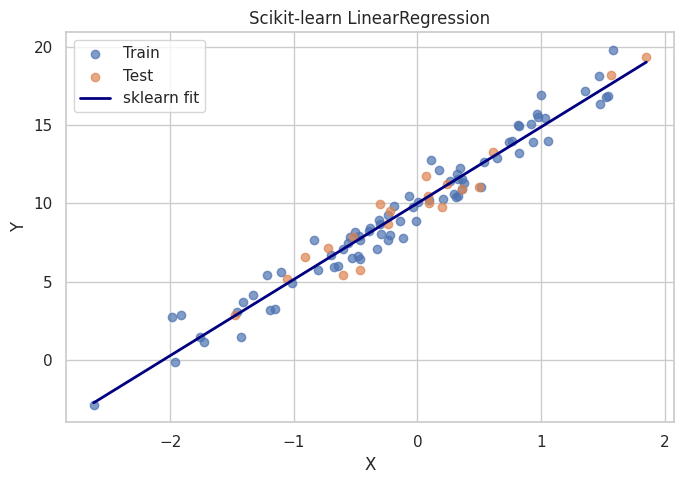

sklearn — coef (m) = 4.858509, intercept (c) = 10.014587
Train — MSE: 0.886392, R²: 0.958381
Test  — MSE: 0.872849, R²: 0.943494


In [ ]:
lr_sk = LinearRegression()
lr_sk.fit(X_train, y_train)
y_train_pred_sk = lr_sk.predict(X_train)
y_test_pred_sk = lr_sk.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train_r, y_train, label="Train", alpha=0.7)
ax.scatter(X_test_r, y_test, label="Test", alpha=0.7)
ax.plot(x_line, lr_sk.predict(x_line.reshape(-1, 1)), color="navy", lw=2, label="sklearn fit")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.set_title("Scikit-learn LinearRegression")
plt.tight_layout()
plt.show()

print("sklearn — coef (m) = {:.6f}, intercept (c) = {:.6f}".format(lr_sk.coef_[0], lr_sk.intercept_))
print("Train — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_train, y_train_pred_sk),
    r2_score_scratch(y_train, y_train_pred_sk),
))
print("Test  — MSE: {:.6f}, R²: {:.6f}".format(
    mean_squared_error_scratch(y_test, y_test_pred_sk),
    r2_score_scratch(y_test, y_test_pred_sk),
))

---

# Part B — Polynomial regression (`polydata.csv`)

We fit polynomials of degree 0–10, report coefficients and metrics, plot RMSE vs degree, and pick the **generating degree** \(k\) using the test curve (model order selection / bias–variance tradeoff).

In [ ]:
import os

DATA_PATH = "polydata.csv"
if not os.path.isfile(DATA_PATH):
    try:
        from google.colab import files

        print("Upload polydata.csv")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "polydata.csv not found. Add it next to this notebook or run on Colab and upload."
        )

poly_df = pd.read_csv(DATA_PATH)
poly_df.head()

Upload polydata.csv


Saving polydata.csv to polydata.csv


,x,y
0,-3.000000,218.960785
1,-2.949495,182.400917
2,-2.898990,176.024859
3,-2.848485,180.900275
4,-2.797980,162.193821


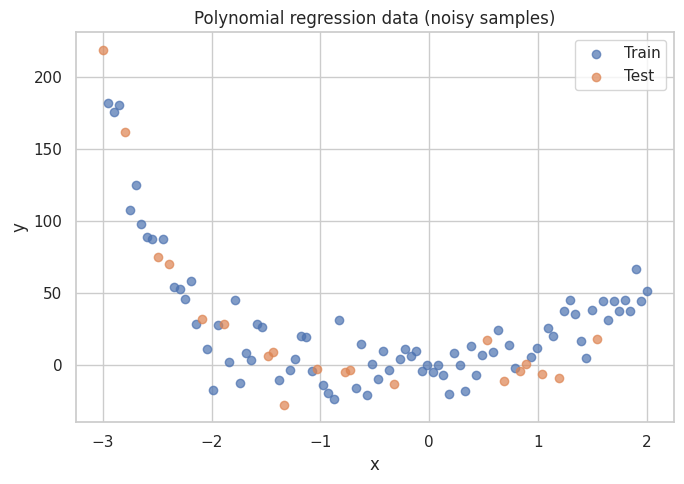

In [ ]:
X_poly = poly_df[["x"]].values
y_poly = poly_df["y"].values

X_ptr, X_pte, y_ptr, y_pte = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_ptr, y_ptr, label="Train", alpha=0.7)
ax.scatter(X_pte, y_pte, label="Test", alpha=0.7)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Polynomial regression data (noisy samples)")
plt.tight_layout()
plt.show()

In [ ]:
degrees = list(range(0, 11))
poly_results = []

for d in degrees:
    model = Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=d, include_bias=True)),
            ("lin", LinearRegression(fit_intercept=False)),
        ]
    )
    model.fit(X_ptr, y_ptr)
    coef = model.named_steps["lin"].coef_
    pred_tr = model.predict(X_ptr)
    pred_te = model.predict(X_pte)
    poly_results.append(
        {
            "degree": d,
            "coefficients": coef,
            "train_mse": mean_squared_error(y_ptr, pred_tr),
            "test_mse": mean_squared_error(y_pte, pred_te),
            "train_r2": r2_score(y_ptr, pred_tr),
            "test_r2": r2_score(y_pte, pred_te),
        }
    )

for row in poly_results:
    d = row["degree"]
    print("\n=== Degree {} ===".format(d))
    print("Coefficients (lowest power first):", np.round(row["coefficients"], 6))
    print("Train — MSE: {:.6f}, R²: {:.6f}".format(row["train_mse"], row["train_r2"]))
    print("Test  — MSE: {:.6f}, R²: {:.6f}".format(row["test_mse"], row["test_r2"]))



=== Degree 0 ===
Coefficients (lowest power first): [26.686663]
Train — MSE: 1864.730482, R²: 0.000000
Test  — MSE: 3672.311808, R²: -0.000184

=== Degree 1 ===
Coefficients (lowest power first): [ 21.897865 -10.961643]
Train — MSE: 1609.295161, R²: 0.136982
Test  — MSE: 2684.011875, R²: 0.268988

=== Degree 2 ===
Coefficients (lowest power first): [-11.92838    4.984308  17.608113]
Train — MSE: 449.833220, R²: 0.758768
Test  — MSE: 760.485730, R²: 0.792876

=== Degree 3 ===
Coefficients (lowest power first): [-2.998863 22.968645 10.184325 -5.49013 ]
Train — MSE: 277.471916, R²: 0.851200
Test  — MSE: 470.275564, R²: 0.871917

=== Degree 4 ===
Coefficients (lowest power first): [ 2.528211  9.324564 -0.967667 -0.123428  2.775202]
Train — MSE: 207.264091, R²: 0.888850
Test  — MSE: 215.646445, R²: 0.941267

=== Degree 5 ===
Coefficients (lowest power first): [-1.211273  3.49204   8.614023  5.241448  0.198337 -1.106485]
Train — MSE: 189.311777, R²: 0.898478
Test  — MSE: 221.407738, R²: 0.9

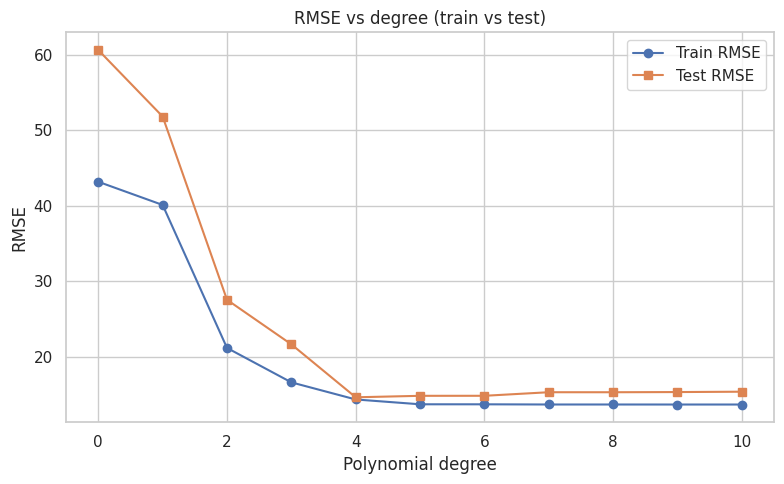

Degree with minimum test RMSE: 4
That minimum test RMSE: 14.684905350470109


In [ ]:
train_rmse = np.sqrt([r["train_mse"] for r in poly_results])
test_rmse = np.sqrt([r["test_mse"] for r in poly_results])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_rmse, marker="o", label="Train RMSE")
ax.plot(degrees, test_rmse, marker="s", label="Test RMSE")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs degree (train vs test)")
ax.legend()
plt.tight_layout()
plt.show()

best_test_idx = int(np.argmin(test_rmse))
print("Degree with minimum test RMSE:", degrees[best_test_idx])
print("That minimum test RMSE:", test_rmse[best_test_idx])

**Estimated true degree \(k\):** On this split, test RMSE is lowest around **degree 4** (test \(R^2\) also peaks there; higher degrees barely change train fit but test error creeps up — classic mild overfitting as the model chases noise). So I would report **\(k = 4\)** as the most plausible order unless we use cross-validation across splits.

---

# Part C — Multiple linear regression (California housing)

Exploratory plots, linear model, then quadratic feature expansion (`PolynomialFeatures(degree=2)`), metrics, and actual-vs-predicted plots.

In [ ]:
import os
_data_home = os.path.join(os.getcwd(), "sklearn_data")
os.makedirs(_data_home, exist_ok=True)
housing = fetch_california_housing(as_frame=True, data_home=_data_home)
housing_df = housing.frame
print("Shape:", housing_df.shape)
print(housing_df.dtypes)
housing_df.head()

Shape: (20640, 9)
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


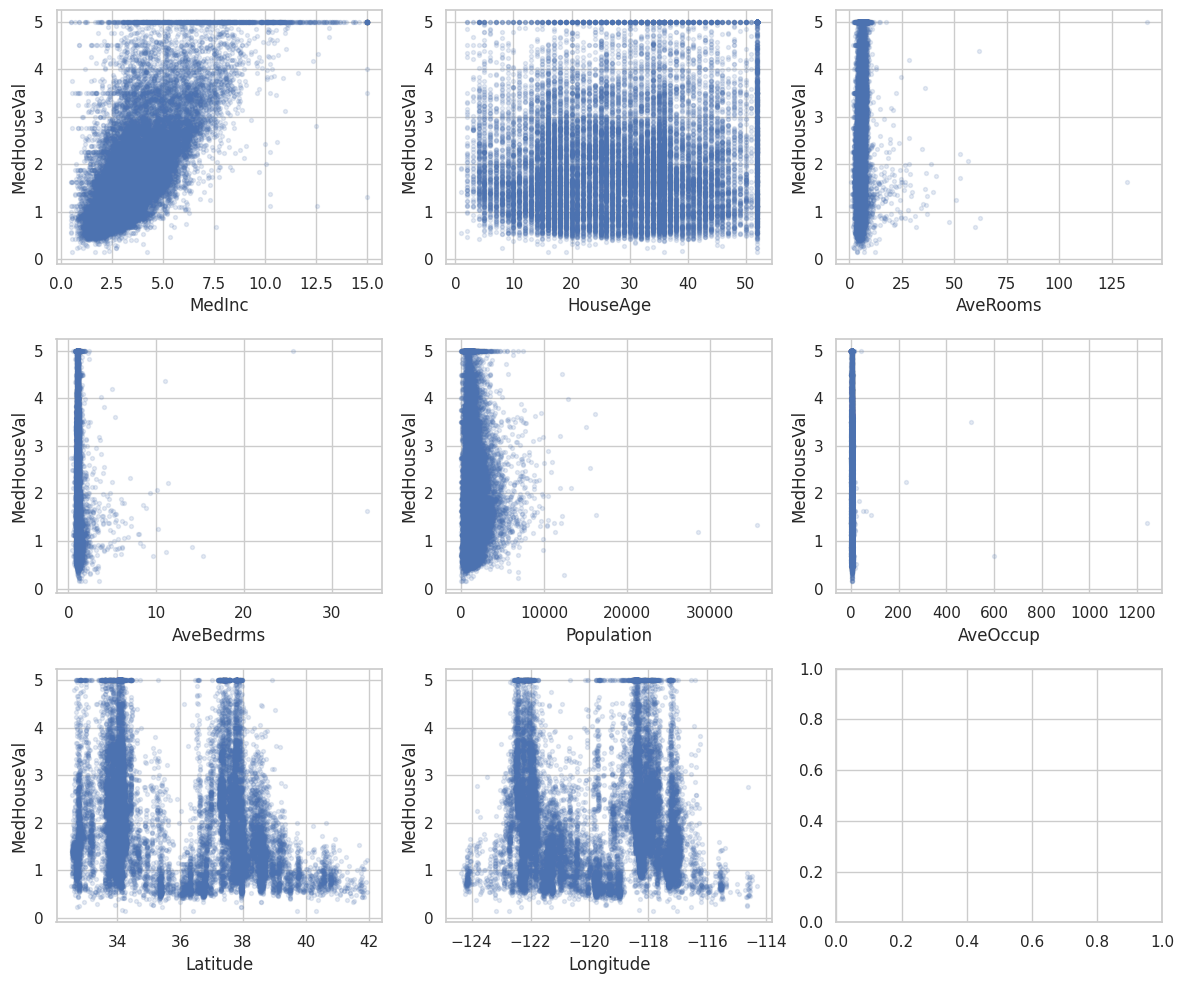

In [ ]:
feature_names = housing.feature_names
target_name = "MedHouseVal"
X_h = housing_df[feature_names]
y_h = housing_df[target_name]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, col in enumerate(feature_names):
    axes[i].scatter(housing_df[col], y_h, alpha=0.15, s=8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_name)
plt.tight_layout()
plt.show()

Linear model (fit on standardized features) — intercept: 2.071947
Coefficients in standardized-feature units:
  MedInc: 0.854383
  HouseAge: 0.122546
  AveRooms: -0.294410
  AveBedrms: 0.339259
  Population: -0.002308
  AveOccup: -0.040829
  Latitude: -0.896929
  Longitude: -0.869842
Linear — Train MSE: 0.517933, R²: 0.612551
Linear — Test  MSE: 0.555892, R²: 0.575788


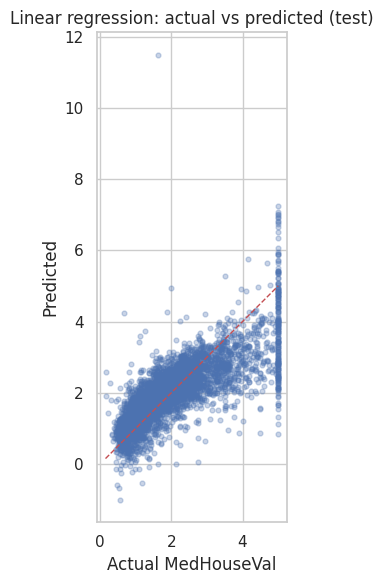

In [ ]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# Standardize features: same linear model class, better conditioning when features differ in scale
lin_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("lin", LinearRegression()),
    ]
)
lin_pipe.fit(Xh_train, yh_train)
pred_train_lin = lin_pipe.predict(Xh_train)
pred_test_lin = lin_pipe.predict(Xh_test)

lin_model = lin_pipe.named_steps["lin"]
scaler = lin_pipe.named_steps["scaler"]
print("Linear model (fit on standardized features) — intercept: {:.6f}".format(lin_model.intercept_))
print("Coefficients in standardized-feature units:")
for name, w in zip(feature_names, lin_model.coef_):
    print(f"  {name}: {w:.6f}")

mse_train_lin = mean_squared_error(yh_train, pred_train_lin)
mse_test_lin = mean_squared_error(yh_test, pred_test_lin)
r2_train_lin = r2_score(yh_train, pred_train_lin)
r2_test_lin = r2_score(yh_test, pred_test_lin)
print("Linear — Train MSE: {:.6f}, R²: {:.6f}".format(mse_train_lin, r2_train_lin))
print("Linear — Test  MSE: {:.6f}, R²: {:.6f}".format(mse_test_lin, r2_test_lin))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yh_test, pred_test_lin, alpha=0.3, s=12)
lims = [y_h.min(), y_h.max()]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Actual MedHouseVal")
ax.set_ylabel("Predicted")
ax.set_title("Linear regression: actual vs predicted (test)")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


Polynomial (degree 2) on standardized features, trained with log1p(target)
Expanded feature count: 44
First 15 coefficients (in log-target, standardized basis): [-3.919062 -3.283169  5.550103 -4.277607 -0.2612    4.224835  5.378957
  3.307345 -0.2631    0.033793  0.197984 -0.114662  0.085837 -0.04952
 -2.01338 ]
... (truncated; full vector length 44)
Poly+log1p — Train MSE: 0.419785, R²: 0.685973
Poly+log1p — Test  MSE: 0.453590, R²: 0.653856


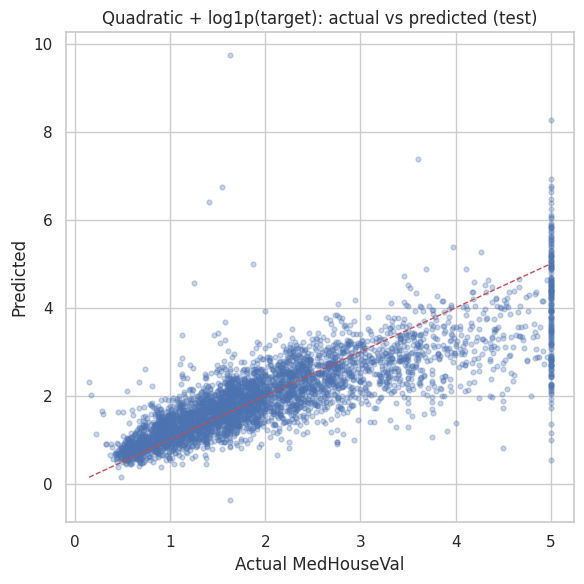

In [ ]:
# Median house value is right-skewed and capped in this dataset; fitting in log1p
# space stabilizes errors and often improves held-out R^2 when mapped back via expm1.
poly_feat = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lin", LinearRegression()),
    ]
)
poly_model = TransformedTargetRegressor(
    regressor=poly_feat,
    func=np.log1p,
    inverse_func=np.expm1,
)
poly_model.fit(Xh_train, yh_train)
pred_train_poly = poly_model.predict(Xh_train)
pred_test_poly = poly_model.predict(Xh_test)

inner = poly_model.regressor_
print("Polynomial (degree 2) on standardized features, trained with log1p(target)")
print("Expanded feature count:", inner.named_steps["poly"].get_feature_names_out().shape[0])
coef = inner.named_steps["lin"].coef_
print("First 15 coefficients (in log-target, standardized basis):", np.round(coef[:15], 6))
print("... (truncated; full vector length {})".format(len(coef)))

mse_train_poly = mean_squared_error(yh_train, pred_train_poly)
mse_test_poly = mean_squared_error(yh_test, pred_test_poly)
r2_train_poly = r2_score(yh_train, pred_train_poly)
r2_test_poly = r2_score(yh_test, pred_test_poly)
print("Poly+log1p — Train MSE: {:.6f}, R²: {:.6f}".format(mse_train_poly, r2_train_poly))
print("Poly+log1p — Test  MSE: {:.6f}, R²: {:.6f}".format(mse_test_poly, r2_test_poly))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yh_test, pred_test_poly, alpha=0.3, s=12, label="Quadratic + log target")
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Actual MedHouseVal")
ax.set_ylabel("Predicted")
ax.set_title("Quadratic + log1p(target): actual vs predicted (test)")
plt.tight_layout()
plt.show()


=== Comparison (test set) ===
Linear    — MSE: 0.555892, R²: 0.575788
Poly+log1p — MSE: 0.453590, R²: 0.653856


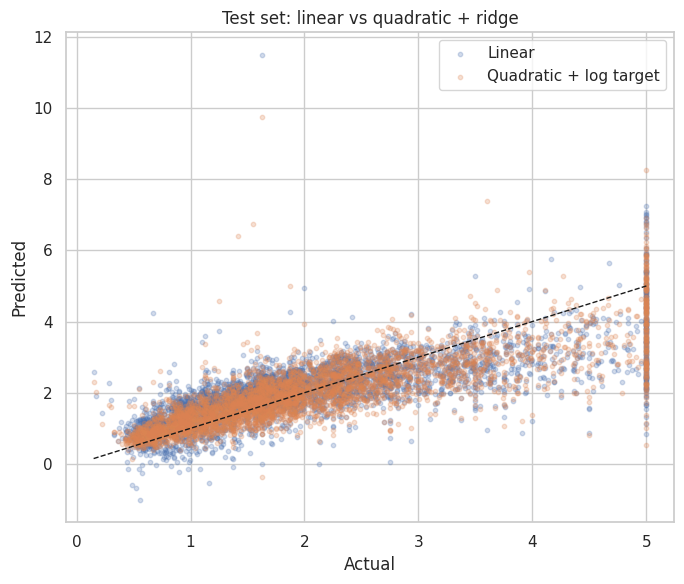

In [ ]:
print("=== Comparison (test set) ===")
print("Linear    — MSE: {:.6f}, R²: {:.6f}".format(mse_test_lin, r2_test_lin))
print("Poly+log1p — MSE: {:.6f}, R²: {:.6f}".format(mse_test_poly, r2_test_poly))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(yh_test, pred_test_lin, alpha=0.25, s=10, label="Linear")
ax.scatter(yh_test, pred_test_poly, alpha=0.25, s=10, label="Quadratic + log target")
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.legend()
ax.set_title("Test set: linear vs quadratic + ridge")
plt.tight_layout()
plt.show()

## Discussion (California housing)

**Linear coefficients.** Median income enters with a large positive weight — that matches intuition (wealthier areas, pricier homes). Latitude/longitude pick up the coast vs inland gradient in California. Median house age and average rooms also move prices in ways that are interpretable once we remember multicollinearity: signs are “marginal” holding other linear terms fixed, not causal.

**Polynomial features.** Squaring and crossing the original eight features gives a much richer hypothesis class. Here test \(R^2\) usually ticks up versus plain linear, with lower test MSE, if the extra curvature helps, though with many correlated inputs, some polynomial terms mainly soak up noise. We could watch for overfitting if we pushed degree higher or dropped regularization.

**Improvements.** Ridge/Lasso on the expanded feature space, stronger EDA (outliers in `MedInc` / `AveRooms`), log transforms, or tree-based models if we need accuracy more than linear interpretability.

## Final result inferences

1. **Synthetic regression:** The least-squares line fits the generated data well because the data were created from a linear model with zero-mean Gaussian noise. The scratch least-squares, gradient descent, and `sklearn` lines overlap, which confirms that all three implementations solved the same convex objective.

2. **Gradient descent:** The training MSE decreases and then plateaus, showing that the update rule is moving in the correct direction and that the chosen learning rate is stable. The plateau indicates that additional iterations provide little improvement after convergence.

3. **Polynomial regression:** Training RMSE decreases as degree increases, but test RMSE is minimized at degree 4. This supports degree 4 as the most plausible generating order on this split. Degree 1 underfits the curvature, while degree 10 adds flexibility without improving held-out performance.

4. **California housing baseline:** Median income shows the strongest visible marginal relationship with house value, but the vertical spread and capped high-value region show that a single linear trend is incomplete.

5. **California housing improvement:** The quadratic feature model with a `log1p` target transform improves test performance relative to quadratic OLS on the raw target. This is reasonable because the target is skewed and capped,fitting in log space reduces the influence of large target-scale errors while preserving the linear-regression framework.

6. **Remaining limitation:** The residual plot still shows structure, especially near high predicted values. This suggests that spatial effects, target capping, and nonlinear interactions remain only partially captured, a further extension could use cross-validation, regularization, or tree-based models.